### Question 1

Largest blobs (row, col, sigma):
(np.int64(338), np.int64(281), np.float64(8.5))
(np.int64(337), np.int64(282), np.float64(8.5))
(np.int64(275), np.int64(1), np.float64(8.5))
(np.int64(339), np.int64(282), np.float64(8.5))
(np.int64(338), np.int64(282), np.float64(8.5))
(np.int64(274), np.int64(0), np.float64(8.5))
(np.int64(275), np.int64(0), np.float64(8.5))
(np.int64(339), np.int64(283), np.float64(8.5))
(np.int64(338), np.int64(283), np.float64(8.5))
(np.int64(339), np.int64(281), np.float64(8.0))


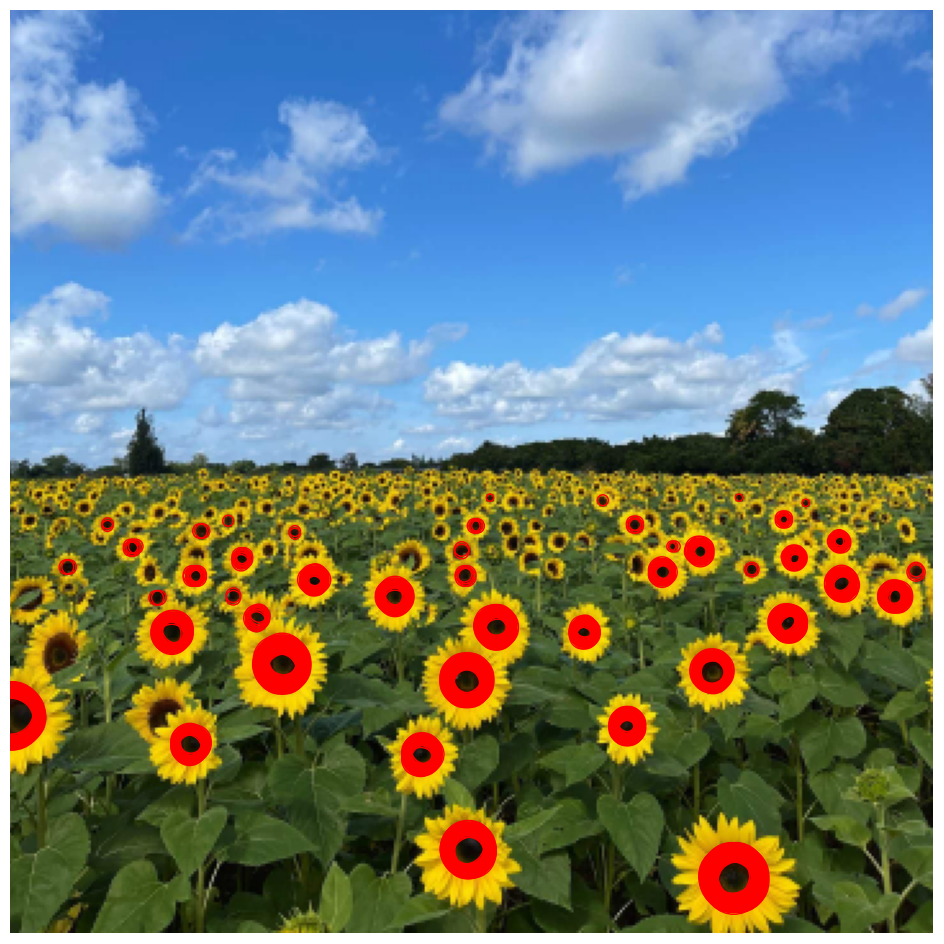

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


def detect_blobs_log(gray_img, sigma_limits, sigma_step, response_threshold):
    blobs_list = []
    sigma_values = np.arange(sigma_limits[0], sigma_limits[1] + sigma_step, sigma_step)

    for sigma in sigma_values:
        # Apply Gaussian blur
        blurred = cv.GaussianBlur(gray_img, (0, 0), sigmaX=sigma, sigmaY=sigma)
        # Compute Laplacian
        log_response = cv.Laplacian(blurred, cv.CV_32F)
        log_response = (sigma**2 * log_response)**2  # squared response

        # Find points above threshold
        detected_points = np.argwhere(log_response >= response_threshold)

        # Append blobs with current sigma
        for r, c in detected_points:
            blobs_list.append((r, c, sigma))

    # Remove duplicates
    blobs_list = list(set(blobs_list))
    return blobs_list


def plot_blob_circles(axis, blobs, color='red', linewidth=1, fill=False):
    for row, col, sigma in blobs:
        radius = sigma * np.sqrt(2)
        circle = plt.Circle((col, row), radius, color=color, linewidth=linewidth, fill=fill)
        axis.add_patch(circle)

# Load image
image_path = 'the_berry_farms_sunflower_field.jpeg'
color_img = cv.imread(image_path, cv.IMREAD_REDUCED_COLOR_4)
gray_img = cv.cvtColor(color_img, cv.COLOR_BGR2GRAY)
gray_img = gray_img.astype(np.float32) / 255.0

all_blobs = detect_blobs_log(gray_img, sigma_limits=(1, 10), sigma_step=0.5, response_threshold=0.095)

# Sort largest blobs by sigma
largest_blobs = sorted(all_blobs, key=lambda x: x[2], reverse=True)[:10]

print("Largest blobs (row, col, sigma):")
for blob in largest_blobs:
    print(blob)

# Plot results
plt.figure(figsize=(12, 12))
plt.imshow(cv.cvtColor(color_img, cv.COLOR_BGR2RGB))
ax = plt.gca()
plot_blob_circles(ax, all_blobs, color='red')
ax.set_xlim([0, color_img.shape[1]])
ax.set_ylim([color_img.shape[0], 0])
plt.axis('off')
plt.show()


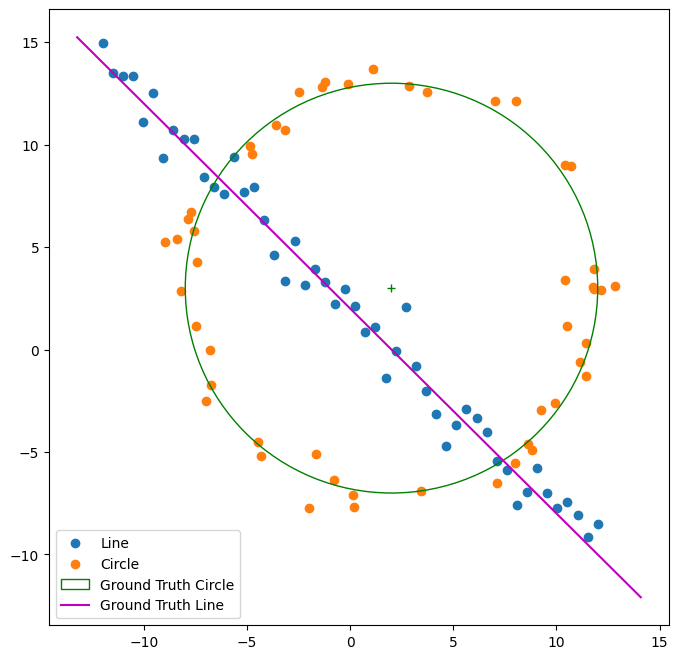

In [13]:
from scipy.optimize import minimize
from scipy import linalg
import numpy as np
import matplotlib.pyplot as plt


# np.random.seed(0)
N = 100
half_n = N // 2

r = 10
x0_gt, y0_gt = 2, 3  # Center

s = r / 16
t = np.random.uniform(0, 2 * np.pi, half_n)
n = s * np.random.randn(half_n)
x, y = x0_gt + (r + n) * np.cos(t), y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

s = 1.0
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m * x + b + s * np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

X = np.vstack((X_circ, X_line))  # All points

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X_line[:, 0], X_line[:, 1], label='Line')
ax.scatter(X_circ[:, 0], X_circ[:, 1], label='Circle')

circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground Truth Circle')
ax.add_patch(circle_gt)
ax.plot(x0_gt, y0_gt, '+', color='g')

x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m * x_ + b
plt.plot(x_, y_, color='m', label='Ground Truth Line')

plt.legend()
plt.show()

### RANSAC line fitting (implementation)

Implement a robust line estimator using RANSAC:

- Model: line in ax + by + d = 0 with ||[a,b]^T|| = 1 (unit normal), d is signed distance from origin.
- Minimal sample: 2 points -> compute unit normal from segment direction; set d = -n^T p0.
- Error: point-to-line normal distance e_i = |a x_i + b y_i + d|.
- Consensus: inliers have e_i <= tau. Choose tau from noise level (data in same units as X).
- Score: pick hypothesis with most inliers; on the winning inliers, refit by Total Least Squares (TLS) and renormalize.
- Iterations: max_iters or until an all-inliers model.


### RANSAC circle fitting (after removing line inliers)

Now fit a circle to the remaining points (those not explained by the best line):

- Model: circle with parameters (x0, y0, r).
- Minimal sample: 3 non-collinear points define a circle; reject collinear or nearly-collinear triplets.
- Error: radial error e_i = |\|x_i - c\| - r| where c = (x0, y0).
- Consensus: inliers satisfy e_i <= tau_circ. Choose tau_circ from the circle noise level (here the circle’s radial noise s ≈ r/16 ≈ 0.625, so tau_circ ≈ 2·s ≈ 1.25 is reasonable to start).
- Scoring: largest inlier set wins; refine with a small nonlinear least squares (scipy.minimize) on inliers to minimize sum of squared radial errors.
- Output: center and radius, inlier indices, and a plot overlaid on the data.



Line (refined TLS): a=0.7264, b=0.6873, d=1.7609  (unit normal a,b)
Line inliers count: 50
RANSAC line sample indices (two pts): (np.int32(89), np.int32(74))

Circle (refined): center=(1.9413, 3.0192), r=9.7883
Circle inliers count: 46
RANSAC circle sample indices (three pts, original indices): [48 36 23]


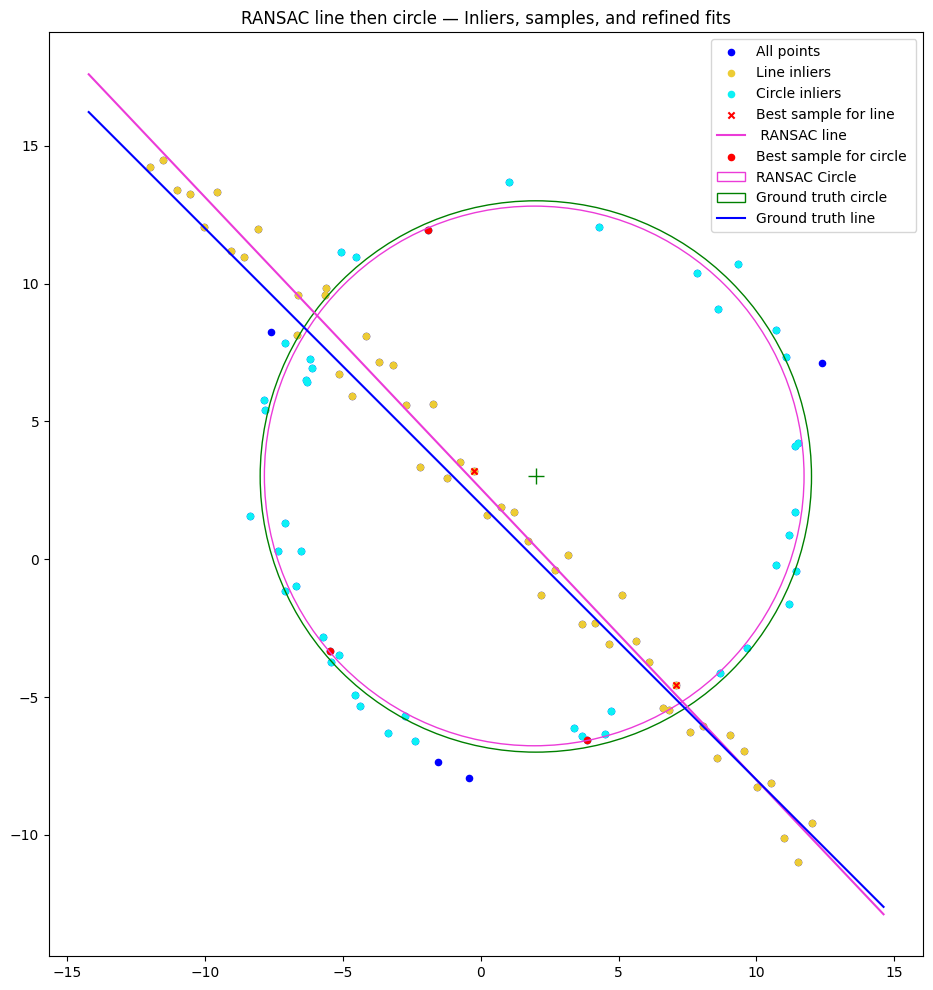

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(0)

N = 100
half_n = N // 2

r = 10.0
x0_gt, y0_gt = 2.0, 3.0  # ground-truth circle center
s_circ = r / 16.0        # circle noise scale
t = np.random.uniform(0, 2*np.pi, half_n)
n_noise = s_circ * np.random.randn(half_n)
x_circ = x0_gt + (r + n_noise) * np.cos(t)
y_circ = y0_gt + (r + n_noise) * np.sin(t)
X_circ = np.hstack((x_circ.reshape(half_n, 1), y_circ.reshape(half_n, 1)))

s_line = 1.0
m, b = -1.0, 2.0
x_line = np.linspace(-12, 12, half_n)
y_line = m * x_line + b + s_line * np.random.randn(half_n)
X_line = np.hstack((x_line.reshape(half_n, 1), y_line.reshape(half_n, 1)))

X = np.vstack((X_circ, X_line))  # all points


def line_from_two_points(p1, p2):
    v = p2 - p1
    n = np.array([v[1], -v[0]])
    norm = np.linalg.norm(n)
    if norm == 0:
        return None
    n_unit = n / norm
    d = float(n_unit.dot(p1))
    return n_unit[0], n_unit[1], d

def point_line_distances(Xpts, a, b, d):
    return np.abs(Xpts.dot(np.array([a, b])) - d)

def refine_line_tls(X_inliers):
    if len(X_inliers) < 2:
        return None
    centroid = X_inliers.mean(axis=0)
    centered = X_inliers - centroid
    U, S, Vt = np.linalg.svd(centered, full_matrices=False)
    normal = Vt[-1, :]
    normal = normal / np.linalg.norm(normal)
    a, b = normal
    d = float(normal.dot(centroid))
    return a, b, d

def circle_from_points(p1, p2, p3):
    A = np.array([p1, p2, p3], dtype=float)
    mat = np.vstack((A.T, np.ones(3)))
    if np.linalg.matrix_rank(mat) < 3:
        return None
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    
    a = x1 - x2
    b = y1 - y2
    c = x1 - x3
    d = y1 - y3
    e = ((x1**2 - x2**2) + (y1**2 - y2**2)) / 2.0
    f = ((x1**2 - x3**2) + (y1**2 - y3**2)) / 2.0
    denom = a * d - b * c
    if abs(denom) < 1e-8:
        return None
    x0 = (d*e - b*f) / denom
    y0 = (-c*e + a*f) / denom
    r = np.sqrt((x1 - x0)**2 + (y1 - y0)**2)
    return x0, y0, r

def radial_errors(Xpts, x0, y0, r):
    dists = np.sqrt((Xpts[:,0]-x0)**2 + (Xpts[:,1]-y0)**2)
    return np.abs(dists - r)

def ransac_line(Xpts, iterations=1000, threshold=1.5, min_inliers=30):
    best = {'inliers': None, 'a': None, 'b': None, 'd': None, 'sample_idx': None}
    n_pts = len(Xpts)
    for it in range(iterations):
        i, j = np.random.choice(n_pts, size=2, replace=False)
        p1, p2 = Xpts[i], Xpts[j]
        params = line_from_two_points(p1, p2)
        if params is None:
            continue
        a, b, d = params
        dists = point_line_distances(Xpts, a, b, d)
        inliers_idx = np.where(dists < threshold)[0]
        if len(inliers_idx) > (best['inliers'].sum() if isinstance(best['inliers'], np.ndarray) else 0):
            if len(inliers_idx) >= min_inliers:
                best['inliers'] = inliers_idx
                best['a'], best['b'], best['d'] = a, b, d
                best['sample_idx'] = (i, j)
    
    if best['inliers'] is None:
        return None
    X_in = Xpts[best['inliers']]
    refined = refine_line_tls(X_in)
    if refined is None:
        return None
    best['a'], best['b'], best['d'] = refined
    return best


def ransac_circle(Xpts, iterations=1500, threshold=1.5, min_inliers=20):
    best = {'inliers': None, 'x0': None, 'y0': None, 'r': None, 'sample_idx': None}
    n_pts = len(Xpts)
    for it in range(iterations):
        idx = np.random.choice(n_pts, size=3, replace=False)
        p1, p2, p3 = Xpts[idx]
        circ = circle_from_points(p1, p2, p3)
        if circ is None:
            continue
        x0, y0, r = circ
        errs = radial_errors(Xpts, x0, y0, r)
        inliers_idx = np.where(errs < threshold)[0]
        if best['inliers'] is None or len(inliers_idx) > len(best['inliers']):
            if len(inliers_idx) >= min_inliers:
                best['inliers'] = inliers_idx
                best['x0'], best['y0'], best['r'] = x0, y0, r
                best['sample_idx'] = idx
    if best['inliers'] is None:
        return None

    X_in = Xpts[best['inliers']]
    def objective(params):
        cx, cy, rr = params
        if rr <= 0:
            return 1e6
        errs = radial_errors(X_in, cx, cy, rr)
        return np.sum(errs**2)

    x0_init, y0_init, r_init = best['x0'], best['y0'], best['r']
    res = minimize(objective, x0=np.array([x0_init, y0_init, r_init]),
                   bounds=[(None, None), (None, None), (1e-3, None)])
    if res.success:
        best['x0'], best['y0'], best['r'] = res.x
    return best


line_iterations = 1000
line_threshold = 1.2   
line_min_inliers = 40

circle_iterations = 1500
circle_threshold = 1
circle_min_inliers = 15

# 1) Estimate line using RANSAC
line_result = ransac_line(X, iterations=line_iterations, threshold=line_threshold, min_inliers=line_min_inliers)
if line_result is None:
    raise RuntimeError("Line RANSAC failed to find a model")

# compute distances and inliers again with refined params
a_best, b_best, d_best = line_result['a'], line_result['b'], line_result['d']
dists_all = point_line_distances(X, a_best, b_best, d_best)
line_inliers_idx = np.where(dists_all < line_threshold)[0]
line_sample_idx = line_result['sample_idx']

# 2) Subtract line inliers and estimate circle on remainder
mask_remnant = np.ones(len(X), dtype=bool)
mask_remnant[line_inliers_idx] = False
X_remnant = X[mask_remnant]

circle_result = ransac_circle(X_remnant, iterations=circle_iterations,
                              threshold=circle_threshold, min_inliers=circle_min_inliers)
if circle_result is None:
    raise RuntimeError("Circle RANSAC failed to find a model")

x0_ransac, y0_ransac, r_ransac = circle_result['x0'], circle_result['y0'], circle_result['r']
circle_inliers_idx_in_remnant = circle_result['inliers']

remnant_indices = np.where(mask_remnant)[0]
circle_inliers_idx = remnant_indices[circle_inliers_idx_in_remnant]
circle_sample_idx_remnant = circle_result['sample_idx']
circle_sample_idx = remnant_indices[circle_sample_idx_remnant]


print("Line (refined TLS): a={:.4f}, b={:.4f}, d={:.4f}  (unit normal a,b)".format(a_best, b_best, d_best))
print("Line inliers count:", len(line_inliers_idx))
print("RANSAC line sample indices (two pts):", line_sample_idx)
print()
print("Circle (refined): center=({:.4f}, {:.4f}), r={:.4f}".format(x0_ransac, y0_ransac, r_ransac))
print("Circle inliers count:", len(circle_inliers_idx))
print("RANSAC circle sample indices (three pts, original indices):", circle_sample_idx)


fig, ax = plt.subplots(1, 1, figsize=(12, 12))
ax.set_aspect('equal', 'box')

# Plot all points (light gray)
ax.scatter(X[:,0], X[:,1], s=20, c='blue',marker='o', label='All points')

# Plot line inliers
ax.scatter(X[line_inliers_idx,0], X[line_inliers_idx,1], s=20, c='#EDCC34', marker='o', label='Line inliers')

# Plot circle inliers
ax.scatter(X[circle_inliers_idx,0], X[circle_inliers_idx,1], s=20, c='#0CF1F5', marker='o', label='Circle inliers')

# Plot RANSAC line sample points (from best sample)
p1_idx, p2_idx = line_sample_idx
ax.scatter(X[p1_idx,0], X[p1_idx,1], s=20, c='red' ,marker='x', label='Best sample for line')
ax.scatter(X[p2_idx,0], X[p2_idx,1], s=20, c='red', marker='x')

# Plot best-fit TLS line 
x_min, x_max = ax.get_xlim()
xs = np.linspace(x_min-1, x_max+1, 200)

if abs(b_best) > 1e-6:
    ys = (d_best - a_best*xs) / b_best
    ax.plot(xs, ys, '-', color='#EB3BD8', label=' RANSAC line')
else:
    # vertical-ish line
    x_line_val = d_best / a_best
    ax.plot([x_line_val, x_line_val], [x_min-10, x_max+10], '-', color='#EB3BD8', label=' RANSAC line')

# Plot RANSAC circle sample points
ax.scatter(X[circle_sample_idx,0], X[circle_sample_idx,1], s=20, c='red' ,marker='o', label='Best sample for circle ')

# Plot refined circle
circle_patch = plt.Circle((x0_ransac, y0_ransac), r_ransac, fill=False, label='RANSAC Circle', color='#EB3BD8')
ax.add_patch(circle_patch)
# plot ground truth circle & center
gt_circle = plt.Circle((x0_gt, y0_gt), r, fill=False, color='green', label='Ground truth circle')
ax.add_patch(gt_circle)
ax.plot(x0_gt, y0_gt, '+', color='green', markersize=12)

# plot ground truth line for reference
# ground truth line: y = m*x + b
xt = np.array([x_min-1, x_max+1])
yt = m*xt + b
ax.plot(xt, yt, color='blue', label='Ground truth line')

ax.legend()
ax.set_title('RANSAC line then circle — Inliers, samples, and refined fits')
plt.show()


### What will happen if we fit the circle first?

If we fit the circle first, the algorithm will try to make a circle that includes as many points as possible, even if some of those points actually belong to the line. Because of this, the circle’s center and radius will not be correct, they’ll shift to cover both circle and line points. Then, when we fit the line using the remaining points, there will be fewer true line points left, so the line will also not fit properly. Overall, fitting the circle first mixes up the two shapes, leading to wrong inlier classification and higher fitting errors for both the circle and the line.

In [228]:
import cv2
import numpy as np


image_pairs = [
    {"background": "canvas.png", "foreground": "art.jpg"},
    {"background": "billboard.png", "foreground": "peanut.jpg"}
]


def overlay_foreground(bg_path, fg_path):
    bg = cv2.imread(bg_path)
    fg = cv2.imread(fg_path)

    if bg is None or fg is None:
        raise ValueError(f"Could not load images: {bg_path}, {fg_path}")

    # Resize foreground if too large
    fg_h, fg_w = fg.shape[:2]
    scale_factor = 400 / max(fg_h, fg_w)
    if scale_factor < 1.0:
        fg = cv2.resize(fg, (int(fg_w*scale_factor), int(fg_h*scale_factor)))
        fg_h, fg_w = fg.shape[:2]

    # Click four points on background
    points = []
    display = bg.copy()

    def click_event(event, x, y, flags, param):
        nonlocal points, display
        if event == cv2.EVENT_LBUTTONDOWN:
            points.append([x, y])
            print(f"Point clicked: {x}, {y}")
            cv2.circle(display, (x, y), 5, (0, 0, 255), -1)
            cv2.imshow("Select 4 points", display)

    print(f"Click 4 points on {bg_path} where you want to place the foreground image.")
    cv2.imshow("Select 4 points", display)
    cv2.setMouseCallback("Select 4 points", click_event)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    if len(points) != 4:
        raise ValueError("You must click exactly 4 points.")

    points = np.array(points, dtype=np.float32)

    # corners of foreground
    src_pts = np.array([[0,0], [fg_w,0], [fg_w, fg_h], [0, fg_h]], dtype=np.float32)

    # Compute homography
    H, _ = cv2.findHomography(src_pts, points)

    # Warp foreground
    bg_h, bg_w = bg.shape[:2]
    warped_fg = cv2.warpPerspective(fg, H, (bg_w, bg_h))

    # Create mask
    gray = cv2.cvtColor(warped_fg, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    mask_inv = cv2.bitwise_not(mask)

    # Blend
    bg_area = cv2.bitwise_and(bg, bg, mask=mask_inv)
    fg_area = cv2.bitwise_and(warped_fg, warped_fg, mask=mask)
    result = cv2.add(bg_area, fg_area)

    # Show & save
    cv2.imshow("Result", result)
    #out_name = fg_path.replace(".png", "_on_" + bg_path)
    #cv2.imwrite(out_name, result)
    #print(f"Result saved as {out_name}")
    cv2.waitKey(0)
    cv2.destroyAllWindows()

for pair in image_pairs:
    overlay_foreground(pair["background"], pair["foreground"])


Click 4 points on canvas.png where you want to place the foreground image.
Point clicked: 203, 99
Point clicked: 582, 100
Point clicked: 582, 479
Point clicked: 203, 478
Click 4 points on billboard.png where you want to place the foreground image.
Point clicked: 226, 179
Point clicked: 461, 174
Point clicked: 466, 347
Point clicked: 227, 351


Detecting SIFT and matching...
Total keypoints img1: 2619, img5: 3504
Good matches after ratio test: 191


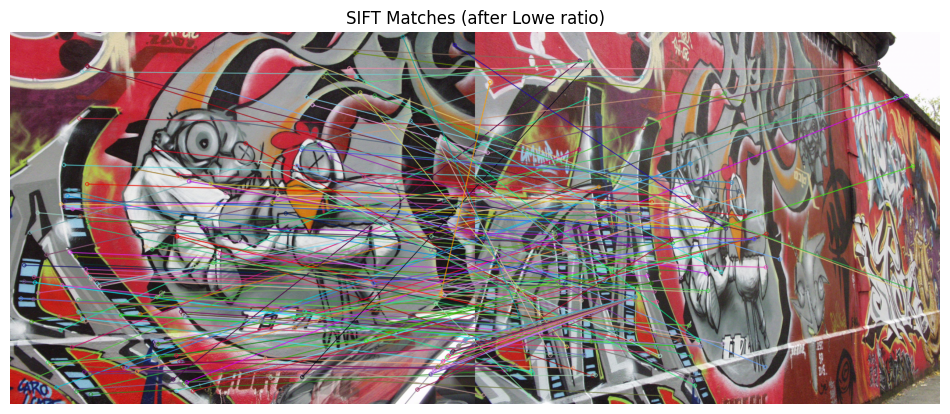

Running custom RANSAC to estimate homography...


C:\Users\user\AppData\Local\Temp\ipykernel_5672\3980890545.py:69: RuntimeWarning: divide by zero encountered in divide
  proj = proj[:, :2] / proj[:, [2]]
C:\Users\user\AppData\Local\Temp\ipykernel_5672\3980890545.py:69: RuntimeWarning: invalid value encountered in divide
  proj = proj[:, :2] / proj[:, [2]]


RANSAC inliers: 28 / 191


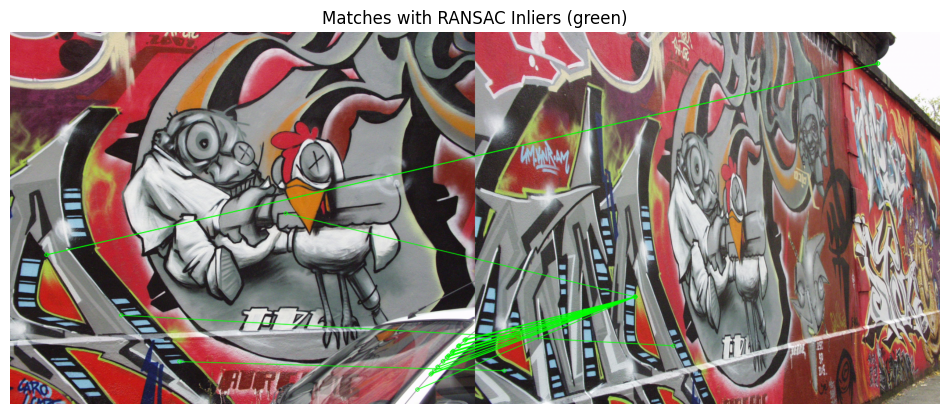

Refined Homography (DLT on inliers):
 [[ 6.65102216e-01 -8.27241425e-01  2.75007773e+02]
 [ 1.10079377e+00 -1.36898032e+00  4.55126459e+02]
 [ 2.41838641e-03 -3.00761401e-03  1.00000000e+00]]
Warping and blending...


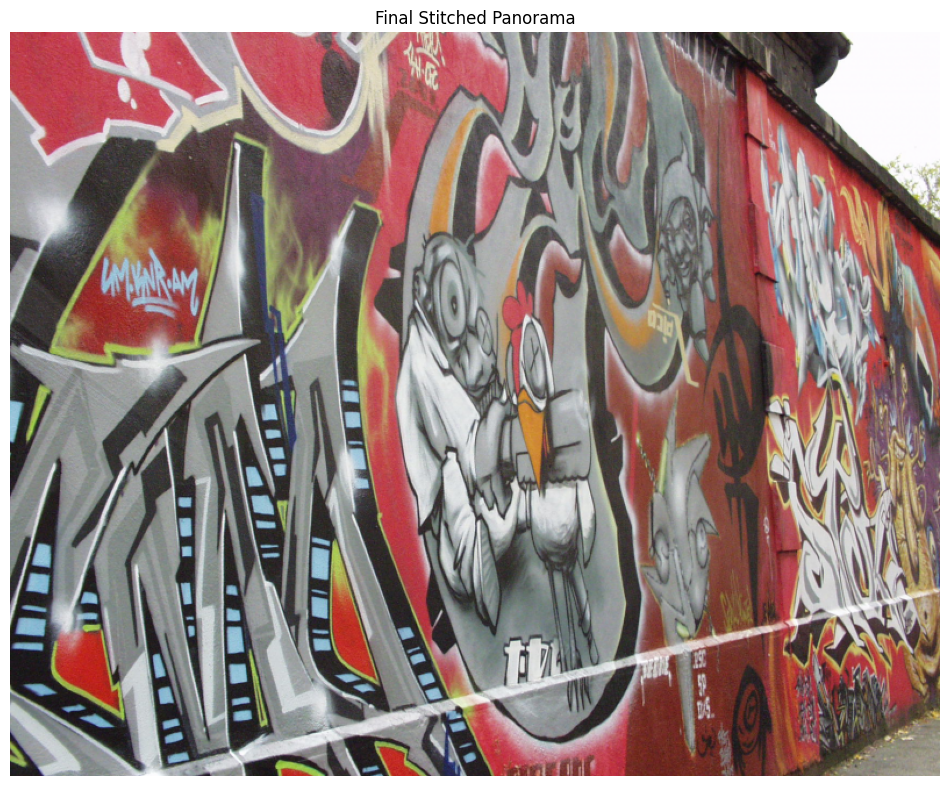

Saved outputs to outputs/


In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import transform
import os


def get_sift_features(img1, img2, ratio_test=0.8):
    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create(nOctaveLayers=3, contrastThreshold=0.095, edgeThreshold=25, sigma=1)
    kp1, des1 = sift.detectAndCompute(img1_gray, None)
    kp2, des2 = sift.detectAndCompute(img2_gray, None)

    bf = cv2.BFMatcher()
    matches_knn = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for m_n in matches_knn:
        if len(m_n) != 2:
            continue
        m, n = m_n
        if m.distance < ratio_test * n.distance:
            good_matches.append(m)

    return good_matches, kp1, kp2

def compute_homography_dlt(src_pts, dst_pts):
    assert src_pts.shape == dst_pts.shape and src_pts.shape[0] >= 4
    N = src_pts.shape[0]
    A = []
    for i in range(N):
        x, y = src_pts[i, 0], src_pts[i, 1]
        xp, yp = dst_pts[i, 0], dst_pts[i, 1]
        A.append([x, y, 1, 0, 0, 0, -xp*x, -xp*y, -xp])
        A.append([0, 0, 0, x, y, 1, -yp*x, -yp*y, -yp])
    A = np.array(A)
    U, S, Vt = np.linalg.svd(A)
    h = Vt[-1, :]
    H = h.reshape(3, 3)
    return H / H[2, 2]

def ransac_homography(matches, kp1, kp2, iterations=2000, reproj_thresh=5.0, sample_size=4, random_seed=0):
    np.random.seed(random_seed)
    n_matches = len(matches)
    all_src = np.array([kp1[m.queryIdx].pt for m in matches])
    all_dst = np.array([kp2[m.trainIdx].pt for m in matches])
    best_H = None
    best_inliers = []
    best_count = 0
    for it in range(iterations):
        samp_idx = np.random.choice(n_matches, sample_size, replace=False)
        src_sample = all_src[samp_idx]
        dst_sample = all_dst[samp_idx]
        try:
            H_candidate = transform.estimate_transform('projective', src_sample, dst_sample).params
        except Exception:
            continue
        src_h = np.hstack([all_src, np.ones((n_matches, 1))])  
        proj = (H_candidate @ src_h.T).T
        proj = proj[:, :2] / proj[:, [2]]

        errors = np.linalg.norm(all_dst - proj, axis=1)
        inlier_idxs = np.where(errors < reproj_thresh)[0]
        count_in = inlier_idxs.shape[0]

        if count_in > best_count:
            best_count = count_in
            best_inliers = inlier_idxs

    refined_H = compute_homography_dlt(all_src[best_inliers], all_dst[best_inliers])

    inlier_mask = np.zeros(n_matches, dtype=bool)
    inlier_mask[best_inliers] = True
    return refined_H, inlier_mask, best_inliers

def draw_matches_and_inliers(img1, img2, kp1, kp2, matches, inlier_mask):
    draw_params = dict(matchColor=(0,255,0),
                       singlePointColor=None,
                       matchesMask=inlier_mask.astype(int).tolist(),
                       flags=cv2.DrawMatchesFlags_DEFAULT)
    img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches, None, **draw_params)
    return img_matches

def warp_and_blend(img1_rgb, img2_rgb, H, blend=True):
    h1, w1 = img1_rgb.shape[:2]
    h2, w2 = img2_rgb.shape[:2]

    corners_img1 = np.array([[0,0],[w1,0],[w1,h1],[0,h1]], dtype=np.float32)
    corners_h = np.hstack([corners_img1, np.ones((4,1))])  
    corners_w = (H @ corners_h.T).T
    corners_w = corners_w[:, :2] / corners_w[:, [2]]

    all_corners = np.vstack((corners_w, np.array([[0,0],[w2,0],[w2,h2],[0,h2]])))
    x_min, y_min = np.floor(all_corners.min(axis=0)).astype(int)
    x_max, y_max = np.ceil(all_corners.max(axis=0)).astype(int)


    translation = np.array([[1,0,-x_min],[0,1,-y_min],[0,0,1]])
    out_w = x_max - x_min
    out_h = y_max - y_min

    H_trans = translation @ H

    img1_f = img1_rgb.astype(np.float32) / 255.0
    img2_f = img2_rgb.astype(np.float32) / 255.0

    warped1 = cv2.warpPerspective((img1_f*255).astype(np.uint8), H_trans, (out_w, out_h))
    warped1 = warped1.astype(np.float32) / 255.0


    canvas = np.zeros((out_h, out_w, 3), dtype=np.float32)
    tx = -x_min
    ty = -y_min
    tx = int(tx); ty = int(ty)
    canvas[ty:ty+h2, tx:tx+w2] = img2_f

    mask1 = (warped1.sum(axis=2) > 0).astype(np.float32)[..., None]
    mask2 = (canvas.sum(axis=2) > 0).astype(np.float32)[..., None]

    if blend:
        overlap = (mask1 * mask2)
        only1 = mask1 - overlap
        only2 = mask2 - overlap

        blended = np.zeros_like(canvas)
        blended += warped1 * only1
        blended += canvas * only2

        if overlap.sum() > 0:
            import scipy.ndimage as ndi
            # distance inside overlap for each image mask
            dist1 = ndi.distance_transform_edt((warped1.sum(axis=2) > 0).astype(np.uint8))
            dist2 = ndi.distance_transform_edt((canvas.sum(axis=2) > 0).astype(np.uint8))
            w1 = dist1 / (dist1 + dist2 + 1e-8)
            w2 = dist2 / (dist1 + dist2 + 1e-8)
            w1 = w1[..., None]; w2 = w2[..., None]
            blended += warped1 * overlap * w1 + canvas * overlap * w2
    else:
        
        blended = canvas.copy()
        blended[mask1[...,0] > 0] = warped1[mask1[...,0] > 0]

    blended = np.clip(blended, 0.0, 1.0)
    blended_uint8 = (blended * 255).astype(np.uint8)
    return blended_uint8


def main():
    img1_path = os.path.join("graf", "img1.ppm")
    img5_path = os.path.join("graf", "img5.ppm")

    # Read images (BGR)
    img1_bgr = cv2.imread(img1_path)
    img5_bgr = cv2.imread(img5_path)
    if img1_bgr is None or img5_bgr is None:
        raise FileNotFoundError("Could not read images. Check paths.")

    # Keep copies as BGR for OpenCV drawing, but convert to RGB for warp/blend/plt
    img1_rgb = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)
    img5_rgb = cv2.cvtColor(img5_bgr, cv2.COLOR_BGR2RGB)

    print("Detecting SIFT and matching...")
    matches, kp1, kp5 = get_sift_features(img1_bgr, img5_bgr, ratio_test=0.8)
    print(f"Total keypoints img1: {len(kp1)}, img5: {len(kp5)}")
    print(f"Good matches after ratio test: {len(matches)}")

    if len(matches) < 8:
        raise RuntimeError("Too few matches - cannot compute reliable homography")

    # Draw raw matches (all good matches)
    matches_img = cv2.drawMatches(img1_bgr, kp1, img5_bgr, kp5, matches, None,
                                  flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(12,8))
    plt.imshow(cv2.cvtColor(matches_img, cv2.COLOR_BGR2RGB))
    plt.title("SIFT Matches (after Lowe ratio)")
    plt.axis('off')
    plt.show()

    # RANSAC to estimate homography
    print("Running custom RANSAC to estimate homography...")
    H_refined, inlier_mask, inlier_idxs = ransac_homography(matches, kp1, kp5,
                                                            iterations=1200,
                                                            reproj_thresh=5.0,
                                                            sample_size=4,
                                                            random_seed=42)
    print(f"RANSAC inliers: {inlier_mask.sum()} / {len(matches)}")

    # Draw matches where inliers == True
    inliers_draw_mask = inlier_mask.astype(int).tolist()
    matches_inliers_img = cv2.drawMatches(img1_bgr, kp1, img5_bgr, kp5, matches, None,
                                         matchColor=(0,255,0),
                                         singlePointColor=(255,0,0),
                                         matchesMask=inliers_draw_mask,
                                         flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(12,8))
    plt.imshow(cv2.cvtColor(matches_inliers_img, cv2.COLOR_BGR2RGB))
    plt.title("Matches with RANSAC Inliers (green)")
    plt.axis('off')
    plt.show()

    print("Refined Homography (DLT on inliers):\n", H_refined)

    # Warp and blend images
    print("Warping and blending...")
    stitched = warp_and_blend(img1_rgb, img5_rgb, H_refined, blend=True)

    plt.figure(figsize=(12,10))
    plt.imshow(stitched)
    plt.title("Final Stitched Panorama")
    plt.axis('off')
    plt.show()

    # Save outputs
    out_dir = "outputs"
    os.makedirs(out_dir, exist_ok=True)
    cv2.imwrite(os.path.join(out_dir, "matches.png"), cv2.cvtColor(matches_img, cv2.COLOR_BGR2RGB)[:,:,::-1])  # save RGB->BGR for cv2
    cv2.imwrite(os.path.join(out_dir, "inlier_matches.png"), cv2.cvtColor(matches_inliers_img, cv2.COLOR_BGR2RGB)[:,:,::-1])
    cv2.imwrite(os.path.join(out_dir, "stitched.png"), cv2.cvtColor(stitched, cv2.COLOR_RGB2BGR))
    print(f"Saved outputs to {out_dir}/")

if __name__ == "__main__":
    main()
